<a href="https://colab.research.google.com/github/BamlakHun/housing/blob/main/housing.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression  # (For machine learning approach we use sklearn package)
import statsmodels.api as sm # (For econometrics approach we use statsmodels package)

sns.set()  #if you want to use seaborn themes with matplotlib functions

In [2]:
rand_state= 1000

In [27]:
housing_url = "https://raw.githubusercontent.com/BamlakHun/housing/1bdd9249559fc137cb165202dc18b70f09d38145/housing.csv"

df = pd.read_csv(housing_url)

In [15]:
df.head(10)

,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15
0,Sold Price,DOM,Garage Capacity,HOA Fee,Irregular Shape,Quadrant,School District,Sold Terms,Total Bedrooms,Total Bathrooms,Total Square Feet,Year Built,Zip,year_sold,month_sold,built_after_2000
1,176000,5,2,0,No,NW,Cache,FHA,3,1,1031,1974,84335,2018,9,0
2,225000,6,2,0,No,NW,Cache,Conventional,4,2,2091,1995,84335,2018,7,0
3,274900,14,2,0,No,NW,Cache,Conventional,3,1,2016,1980,84335,2018,11,0
4,175000,16,1,0,No,NW,Cache,USDA Rural Development,4,1,1920,1978,84335,2018,6,0
5,179000,29,0,0,No,NW,Cache,Cash,4,2,1329,1976,84335,2018,9,0
6,299900,130,2,0,No,NW,Cache,Conventional,6,3,2765,1926,84335,2018,9,0
7,424000,463,6,0,No,NW,Cache,Conventional,4,4,5000,1933,84335,2019,12,0
8,775000,37,2,0,No,SE,Cache,Conventional,5,4,5180,1999,84328,2020,8,0
9,611000,38,2,0,No,SE,Cache,VA,5,3,4308,2015,84328,2020,11,1


In [16]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4111 entries, 0 to 4110
Data columns (total 16 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   0       4111 non-null   object
 1   1       4111 non-null   object
 2   2       4111 non-null   object
 3   3       4111 non-null   object
 4   4       4111 non-null   object
 5   5       4111 non-null   object
 6   6       4111 non-null   object
 7   7       4111 non-null   object
 8   8       4111 non-null   object
 9   9       4111 non-null   object
 10  10      4111 non-null   object
 11  11      4111 non-null   object
 12  12      4111 non-null   object
 13  13      4111 non-null   object
 14  14      4111 non-null   object
 15  15      4111 non-null   object
dtypes: object(16)
memory usage: 514.0+ KB


In [17]:
df.isnull().sum()/len(df)

,0
0,0.0
1,0.0
2,0.0
3,0.0
4,0.0
5,0.0
6,0.0
7,0.0
8,0.0
9,0.0


In [18]:
sum(df.duplicated())

2

In [19]:
df.drop_duplicates(inplace=True)

In [20]:
df.nunique()

,0
0,1218
1,249
2,15
3,97
4,3
5,5
6,3
7,7
8,10
9,8


In [21]:
df.head()

,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15
0,Sold Price,DOM,Garage Capacity,HOA Fee,Irregular Shape,Quadrant,School District,Sold Terms,Total Bedrooms,Total Bathrooms,Total Square Feet,Year Built,Zip,year_sold,month_sold,built_after_2000
1,176000,5,2,0,No,NW,Cache,FHA,3,1,1031,1974,84335,2018,9,0
2,225000,6,2,0,No,NW,Cache,Conventional,4,2,2091,1995,84335,2018,7,0
3,274900,14,2,0,No,NW,Cache,Conventional,3,1,2016,1980,84335,2018,11,0
4,175000,16,1,0,No,NW,Cache,USDA Rural Development,4,1,1920,1978,84335,2018,6,0


In [22]:
ordinal_categorical = ['Irregular Shape', 'Quadrant', 'School District', 'Sold Terms', 'Zip']

In [23]:
from sklearn.preprocessing import OrdinalEncoder

In [24]:
enc = OrdinalEncoder()

In [28]:
df[ordinal_categorical]= enc.fit_transform(df[ordinal_categorical])

In [29]:
df.head()

,Sold Price,DOM,Garage Capacity,HOA Fee,Irregular Shape,Quadrant,School District,Sold Terms,Total Bedrooms,Total Bathrooms,Total Square Feet,Year Built,Zip,year_sold,month_sold,built_after_2000
0,176000,5,2,0,0.0,1.0,0.0,2.0,3,1,1031,1974,12.0,2018,9,0
1,225000,6,2,0,0.0,1.0,0.0,1.0,4,2,2091,1995,12.0,2018,7,0
2,274900,14,2,0,0.0,1.0,0.0,1.0,3,1,2016,1980,12.0,2018,11,0
3,175000,16,1,0,0.0,1.0,0.0,4.0,4,1,1920,1978,12.0,2018,6,0
4,179000,29,0,0,0.0,1.0,0.0,0.0,4,2,1329,1976,12.0,2018,9,0


In [30]:
enc.categories_

[array(['No', 'Yes'], dtype=object),
 array(['NE', 'NW', 'SE', 'SW'], dtype=object),
 array(['Cache', 'Logan'], dtype=object),
 array(['Cash', 'Conventional', 'FHA', 'Other', 'USDA Rural Development',
        'VA'], dtype=object),
 array([84305, 84308, 84318, 84319, 84320, 84321, 84325, 84326, 84327,
        84328, 84332, 84333, 84335, 84338, 84339, 84341])]

In [31]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4110 entries, 0 to 4109
Data columns (total 16 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Sold Price         4110 non-null   int64  
 1   DOM                4110 non-null   int64  
 2   Garage Capacity    4110 non-null   int64  
 3   HOA Fee            4110 non-null   int64  
 4   Irregular Shape    4110 non-null   float64
 5   Quadrant           4110 non-null   float64
 6   School District    4110 non-null   float64
 7   Sold Terms         4110 non-null   float64
 8   Total Bedrooms     4110 non-null   int64  
 9   Total Bathrooms    4110 non-null   int64  
 10  Total Square Feet  4110 non-null   int64  
 11  Year Built         4110 non-null   int64  
 12  Zip                4110 non-null   float64
 13  year_sold          4110 non-null   int64  
 14  month_sold         4110 non-null   int64  
 15  built_after_2000   4110 non-null   int64  
dtypes: float64(5), int64(11)

In [32]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Sold Price,4110.0,282125.245499,117864.718806,13000.0,214000.0,260000.0,324900.00,1900000.0
DOM,4110.0,40.550608,51.571991,1.0,6.0,23.0,56.00,712.0
Garage Capacity,4110.0,1.826034,1.094091,0.0,1.0,2.0,2.00,20.0
HOA Fee,4110.0,36.178345,69.565512,0.0,0.0,0.0,65.00,1050.0
Irregular Shape,4110.0,0.089781,0.285903,0.0,0.0,0.0,0.00,1.0
Quadrant,4110.0,1.511192,1.166685,0.0,0.0,2.0,3.00,3.0
School District,4110.0,0.334550,0.471890,0.0,0.0,0.0,1.00,1.0
Sold Terms,4110.0,1.497810,1.172771,0.0,1.0,1.0,2.00,5.0
Total Bedrooms,4110.0,3.821168,1.182697,1.0,3.0,4.0,5.00,9.0
Total Bathrooms,4110.0,2.577372,0.851165,1.0,2.0,3.0,3.00,7.0


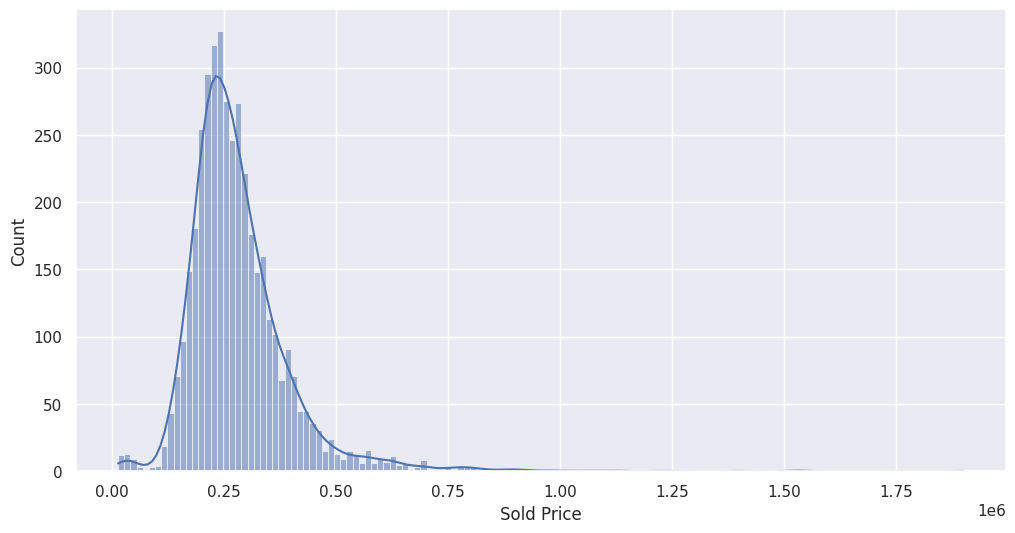

In [92]:
plt.figure(figsize=(12,6))
sns.histplot(df['Sold Price'], kde=True)
plt.show()

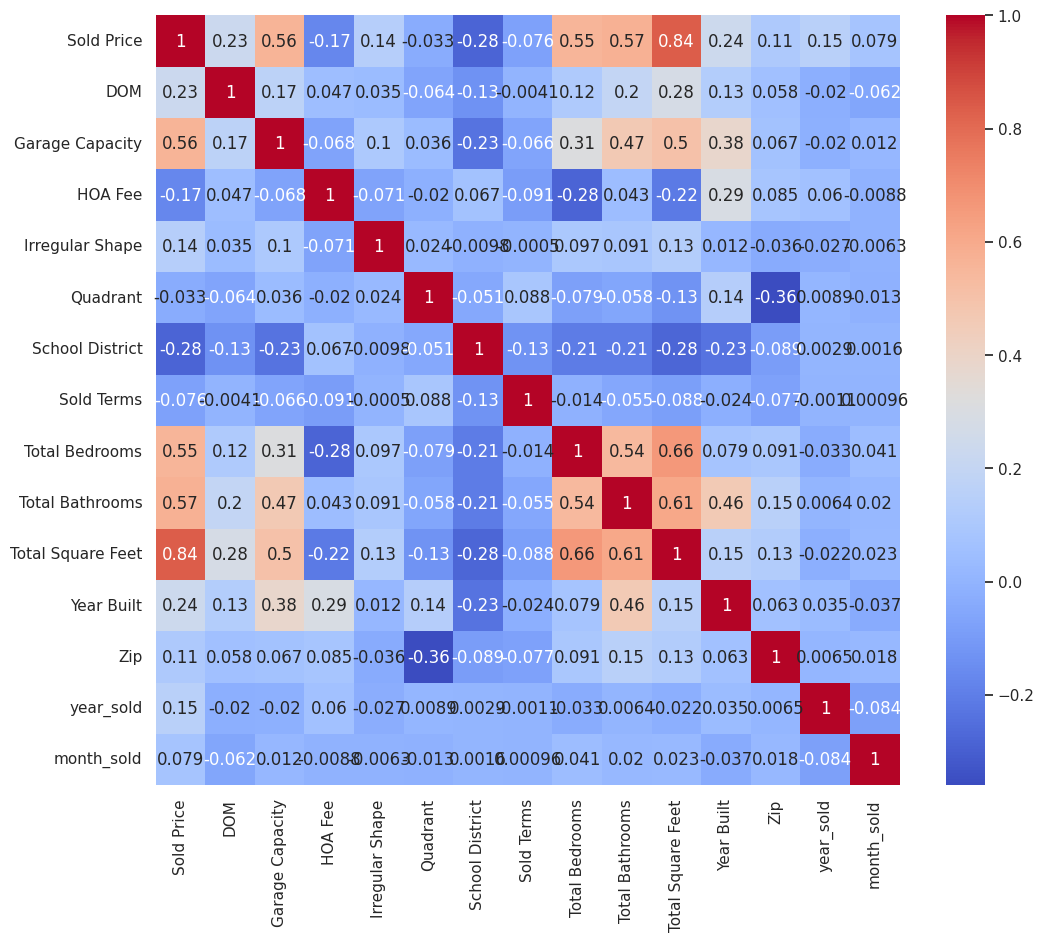

In [74]:
plt.figure(figsize=(12,10))
sns.heatmap(df.corr(), cmap='coolwarm',annot=True)
plt.show()

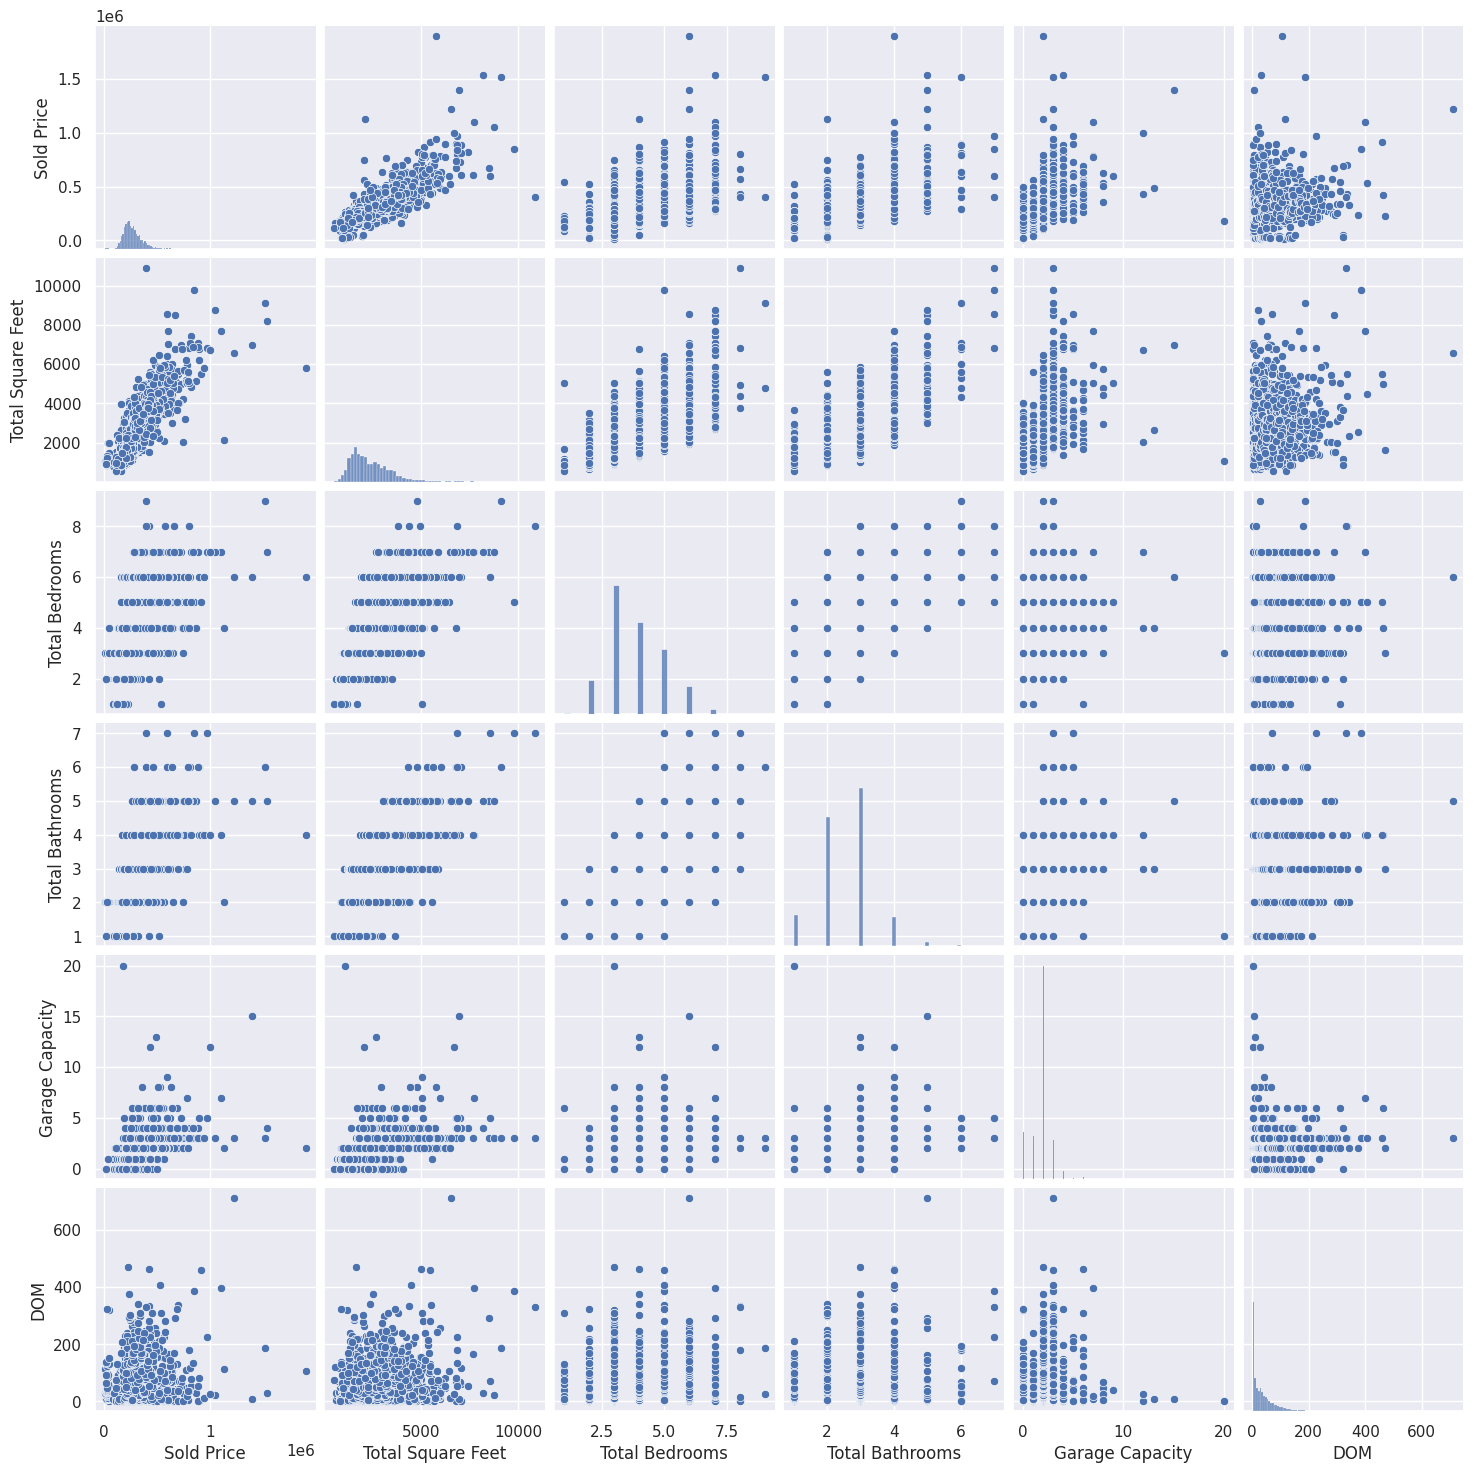

CPU times: user 7.59 s, sys: 48.8 ms, total: 7.64 s
Wall time: 8.27 s


In [77]:
%%time

sns.pairplot(df[['Sold Price','Total Square Feet','Total Bedrooms','Total Bathrooms','Garage Capacity','DOM']])
plt.show()

In [33]:
df.drop('built_after_2000', axis=1, inplace=True) #why?

In [34]:
df.shape

(4110, 15)

In [35]:
rand_state = 1000

In [36]:
y = df['Sold Price']
X = df.drop('Sold Price', axis=1) # becareful inplace= False

from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=rand_state)

RF

In [37]:
from sklearn.ensemble import RandomForestRegressor

In [38]:
RF_regression = RandomForestRegressor(random_state=rand_state)
RF_regression.fit(X_train, y_train)

RandomForestRegressor(random_state=1000)

In [39]:
y_hat = RF_regression.predict(X_test)

In [40]:
predictions = pd.DataFrame({ 'y_test':y_test,'y_hat':y_hat})
predictions.head()

,y_test,y_hat
3940,380000,353917.020000
2470,319000,297391.000000
351,209000,231258.820000
3137,224900,227134.666667
2605,307000,323579.260000


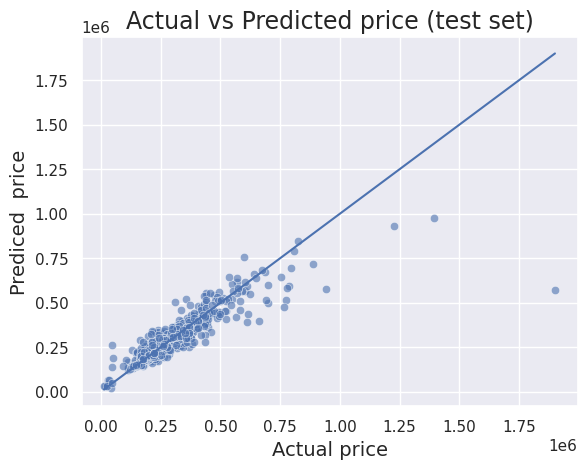

In [48]:
sns.scatterplot(x=y_test, y=y_hat, alpha=0.6)
sns.lineplot(x=y_test, y=y_test)

plt.xlabel('Actual price', fontsize=14)
plt.ylabel('Prediced  price', fontsize=14)
plt.title('Actual vs Predicted price (test set)', fontsize=17)
plt.show()

In [49]:
np.round(RF_regression.score(X_test, y_test),4)

np.float64(0.7866)

In [51]:
MSE_test = round(np.mean(np.square(y_test - y_hat)),2)
RMSE_test = round(np.sqrt(MSE_test),2)
RMSE_test

np.float64(57113.51)

Tuning hyperparameters:
Gridsearch

In [52]:
my_param_grid = {'n_estimators': [10,100,500], 'max_features':['sqrt','log2'], 'max_depth':[5,10,20]}

In [53]:
from sklearn.model_selection import GridSearchCV

In [54]:
GridSearchCV(estimator=RandomForestRegressor(random_state=rand_state),param_grid= my_param_grid, refit = True, verbose=2, cv=5 )

GridSearchCV(cv=5, estimator=RandomForestRegressor(random_state=1000),
             param_grid={'max_depth': [5, 10, 20],
                         'max_features': ['sqrt', 'log2'],
                         'n_estimators': [10, 100, 500]},
             verbose=2)

In [55]:
grid = GridSearchCV(estimator=RandomForestRegressor(random_state=rand_state),param_grid= my_param_grid, refit = True, verbose=2, cv=5 )

In [56]:
grid.fit(X_train,y_train)

Fitting 5 folds for each of 18 candidates, totalling 90 fits
[CV] END ....max_depth=5, max_features=sqrt, n_estimators=10; total time=   0.1s
[CV] END ....max_depth=5, max_features=sqrt, n_estimators=10; total time=   0.1s
[CV] END ....max_depth=5, max_features=sqrt, n_estimators=10; total time=   0.1s
[CV] END ....max_depth=5, max_features=sqrt, n_estimators=10; total time=   0.1s
[CV] END ....max_depth=5, max_features=sqrt, n_estimators=10; total time=   0.1s
[CV] END ...max_depth=5, max_features=sqrt, n_estimators=100; total time=   0.4s
[CV] END ...max_depth=5, max_features=sqrt, n_estimators=100; total time=   0.4s
[CV] END ...max_depth=5, max_features=sqrt, n_estimators=100; total time=   0.3s
[CV] END ...max_depth=5, max_features=sqrt, n_estimators=100; total time=   0.3s
[CV] END ...max_depth=5, max_features=sqrt, n_estimators=100; total time=   0.3s
[CV] END ...max_depth=5, max_features=sqrt, n_estimators=500; total time=   1.4s
[CV] END ...max_depth=5, max_features=sqrt, n_es

GridSearchCV(cv=5, estimator=RandomForestRegressor(random_state=1000),
             param_grid={'max_depth': [5, 10, 20],
                         'max_features': ['sqrt', 'log2'],
                         'n_estimators': [10, 100, 500]},
             verbose=2)

In [57]:
grid.best_params_

{'max_depth': 20, 'max_features': 'sqrt', 'n_estimators': 500}

In [58]:
grid.best_estimator_

RandomForestRegressor(max_depth=20, max_features='sqrt', n_estimators=500,
                      random_state=1000)

In [59]:
y_hat_optimized = grid.predict(X_test)

In [60]:
predictions['y_hat_optimized'] = y_hat_optimized
predictions.head()

,y_test,y_hat,y_hat_optimized
3940,380000,353917.020000,361490.351230
2470,319000,297391.000000,296332.017005
351,209000,231258.820000,229340.583548
3137,224900,227134.666667,227864.208768
2605,307000,323579.260000,327190.802444


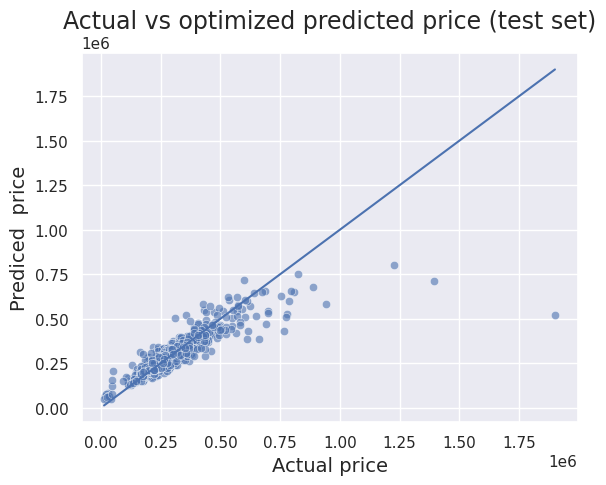

In [72]:
sns.scatterplot(x=y_test, y=y_hat_optimized, alpha=0.6)
sns.lineplot(x=y_test, y=y_test)

plt.xlabel('Actual price', fontsize=14)
plt.ylabel('Prediced  price', fontsize=14)
plt.title('Actual vs optimized predicted price (test set)', fontsize=17)
plt.show()

In [64]:
np.round(grid.score(X_test, y_test),4)

np.float64(0.7529)

In [65]:
MSE_test_opt = round(np.mean(np.square(y_test - y_hat_optimized)),2)
RMSE_test_opt = round(np.sqrt(MSE_test_opt),2)
RMSE_test_opt

np.float64(61456.07)

Feature Importance

In [66]:
features = list(X_train.columns)
features

['DOM',
 'Garage Capacity',
 'HOA Fee',
 'Irregular Shape',
 'Quadrant',
 'School District',
 'Sold Terms',
 'Total Bedrooms',
 'Total Bathrooms',
 'Total Square Feet',
 'Year Built',
 'Zip',
 'year_sold',
 'month_sold']

In [67]:
RF_Regressor = RandomForestRegressor(n_estimators = 500, max_features='sqrt', max_depth=20, random_state= rand_state)
RF_Regressor.fit(X_train, y_train)

RandomForestRegressor(max_depth=20, max_features='sqrt', n_estimators=500,
                      random_state=1000)

In [68]:
importance = RF_Regressor.feature_importances_
importance

array([0.04142181, 0.15543041, 0.04363806, 0.0089106 , 0.01684049,
       0.01781297, 0.02026675, 0.08873011, 0.12021698, 0.35206743,
       0.05892887, 0.02339641, 0.0272106 , 0.0251285 ])

In [79]:
reg_model = LinearRegression()

In [80]:
reg_model.fit(X_train, y_train)

LinearRegression()

In [81]:
y_hat = reg_model.predict(X_test)

In [82]:
df_predictions = pd.DataFrame({'actuals':y_test, 'predictions':y_hat, 'resid': y_test - y_hat})
df_predictions.head()

,actuals,predictions,resid
3940,380000,384775.272213,-4775.272213
2470,319000,290900.518065,28099.481935
351,209000,239868.435598,-30868.435598
3137,224900,247773.974857,-22873.974857
2605,307000,300082.825288,6917.174712


LR Eval

In [83]:
reg_model.score(X_train,y_train)

0.782193409124899

In [84]:
print('Training data R-squared:', np.round(reg_model.score(X_train, y_train),3))
print('Test data R-squared:', np.round(reg_model.score(X_test, y_test),3))

Training data R-squared: 0.782
Test data R-squared: 0.739


MSE & RMSE

In [90]:
MSE_test = np.mean(np.square(df_predictions['resid']))
np.round(MSE_test,3)

np.float64(3984497104.743)

In [91]:
RMSE_test = np.sqrt(MSE_test)
np.round(RMSE_test,3)

np.float64(63122.873)

R-squared

In [85]:
X_train.shape

(2877, 14)

In [86]:
def adj_R2(X,y):
    R2 = reg_model.score(X,y)
    n  = X.shape[0]
    k  = X.shape[1]
    return np.round(1-(1-R2)*(n-1)/(n-k-1),3)

In [87]:
adj_R2(X_train,y_train)

np.float64(0.781)

In [88]:
adj_R2(X_test,y_test)

np.float64(0.736)

In [69]:
FIM = pd.DataFrame({'Features': X_train.columns , 'Feature_importance':importance})
FIM = FIM.sort_values(by=['Feature_importance'])
FIM

,Features,Feature_importance
3,Irregular Shape,0.008911
4,Quadrant,0.016840
5,School District,0.017813
6,Sold Terms,0.020267
11,Zip,0.023396
13,month_sold,0.025129
12,year_sold,0.027211
0,DOM,0.041422
2,HOA Fee,0.043638
10,Year Built,0.058929


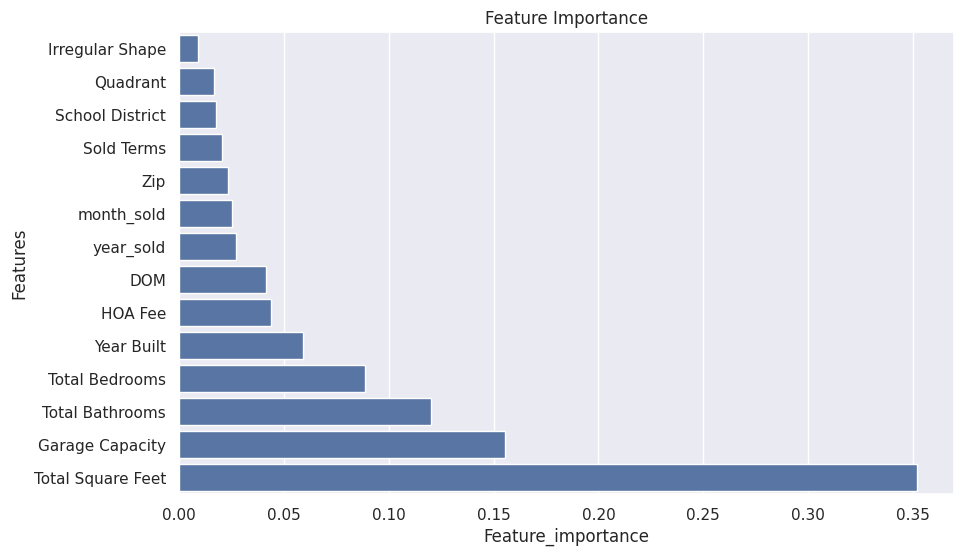

In [70]:
plt.figure(figsize=(10,6))
plt.title('Feature Importance')
sns.barplot(y='Features', x='Feature_importance', data=FIM)
plt.show()